# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example: notebooks/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/data/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
#If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv

#I had significant difficulty pulling happiness data from the direct path, So I moved it in my file so I could pull it easier within the hw_3 folder. Hope that was okay... 
data_dir = os.path.join("data", "hw", "hw_3")       
df_happy = pd.read_parquet("world_happiness.parquet")


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *World Happiness Parquet*, reusing from class but chose the social progress index for the second dataset. 

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
df_happy.info
df_happy.head(2)


,country_name,ladder_score,upperwhisker,lowerwhisker,explained_by:_log_gdp_per_capita,explained_by:_social_support,explained_by:_healthy_life_expectancy,explained_by:_freedom_to_make_life_choices,explained_by:_generosity,explained_by:_perceptions_of_corruption,dystopia_+_residual
0,Finland,7.7407,7.814808,7.666591,1.844054,1.572367,0.694793,0.859294,0.141674,0.546158,2.082367
1,Denmark,7.5827,7.665297,7.500103,1.907798,1.520361,0.698944,0.822740,0.203579,0.548413,1.880887


In [3]:
# 2. Rename columns and select a clean subset
rename_map = {
    "country_name": "country"}
df_happy = df_happy.rename(columns=rename_map)
df_happy.head(2)


,country,ladder_score,upperwhisker,lowerwhisker,explained_by:_log_gdp_per_capita,explained_by:_social_support,explained_by:_healthy_life_expectancy,explained_by:_freedom_to_make_life_choices,explained_by:_generosity,explained_by:_perceptions_of_corruption,dystopia_+_residual
0,Finland,7.7407,7.814808,7.666591,1.844054,1.572367,0.694793,0.859294,0.141674,0.546158,2.082367
1,Denmark,7.5827,7.665297,7.500103,1.907798,1.520361,0.698944,0.822740,0.203579,0.548413,1.880887


In [4]:
# 3. Filter row or column filters if necessary
df_happy.drop(columns=["explained_by:_social_support", "explained_by:_log_gdp_per_capita", "explained_by:_freedom_to_make_life_choices", "explained_by:_generosity"]).tail(2)

,country,ladder_score,upperwhisker,lowerwhisker,explained_by:_healthy_life_expectancy,explained_by:_perceptions_of_corruption,dystopia_+_residual
141,Lebanon,2.7065,2.796744,2.616256,0.556247,0.028772,-0.072831
142,Afghanistan,1.7210,1.775271,1.666728,0.241763,0.088471,0.671903


In [5]:
# 4. Handle missing values (NaNs) if necessary
df_happy.dropna()

,country,ladder_score,upperwhisker,lowerwhisker,explained_by:_log_gdp_per_capita,explained_by:_social_support,explained_by:_healthy_life_expectancy,explained_by:_freedom_to_make_life_choices,explained_by:_generosity,explained_by:_perceptions_of_corruption,dystopia_+_residual
0,Finland,7.7407,7.814808,7.666591,1.844054,1.572367,0.694793,0.859294,0.141674,0.546158,2.082367
1,Denmark,7.5827,7.665297,7.500103,1.907798,1.520361,0.698944,0.822740,0.203579,0.548413,1.880887
2,Iceland,7.5251,7.617527,7.432673,1.880718,1.616525,0.718345,0.818509,0.258344,0.182473,2.050233
3,Sweden,7.3441,7.421563,7.266637,1.878146,1.500826,0.723871,0.838269,0.221455,0.523795,1.657707
4,Israel,7.3411,7.405165,7.277036,1.802934,1.512793,0.739816,0.641463,0.153205,0.192823,2.298026
...,...,...,...,...,...,...,...,...,...,...,...
138,Congo (Kinshasa),3.2954,3.462328,3.128472,0.533670,0.664700,0.261508,0.472705,0.188676,0.072167,1.102014
139,Sierra Leone,3.2452,3.366252,3.124148,0.654278,0.565977,0.253321,0.469035,0.181365,0.053299,1.067906
140,Lesotho,3.1862,3.468785,2.903615,0.770807,0.850587,0.000000,0.523188,0.082087,0.084969,0.874525
141,Lebanon,2.7065,2.796744,2.616256,1.376726,0.576713,0.556247,0.173223,0.067641,0.028772,-0.072831


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
#If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
df_soc_index = pd.read_csv("soc_index_2022.csv")
# 2. Acquire and load your primary dataset
df_soc_index.head(10)
df_soc_index
df_soc_index.rename(columns={"Country": "country"})
df_soc_index = df_soc_index.rename(columns={"Country": "country"})

In [7]:
print(df_happy.columns)
print(df_soc_index.columns)


Index(['country', 'ladder_score', 'upperwhisker', 'lowerwhisker',
       'explained_by:_log_gdp_per_capita', 'explained_by:_social_support',
       'explained_by:_healthy_life_expectancy',
       'explained_by:_freedom_to_make_life_choices',
       'explained_by:_generosity', 'explained_by:_perceptions_of_corruption',
       'dystopia_+_residual'],
      dtype='object')
Index(['Rank', 'country', 'Social Progress Score', 'Basic Human Needs',
       'Foundations of Wellbeing', 'Opportunity',
       'Nutrition and Basic Medical Care', 'Water and Sanitation', 'Shelter',
       'Personal Safety', 'Access to Basic Knowledge',
       'Access to Information and Communications', 'Health and Wellness',
       'Environmental Quality', 'Personal Rights',
       'Personal Freedom and Choice', 'Inclusiveness',
       'Access to Advanced Education'],
      dtype='object')


In [8]:
# 2. Merge your datasets on a common key

df_merged = pd.merge(
    df_happy, 
    df_soc_index, 
    on='country', 
    how='inner', 
    suffixes=('_happy', '_soc'))
print(f"Total merged records: {len(df_merged)}")
print("\n--- Merged Columns ---")
print(df_merged.columns.tolist())

df_merged.head(5)

Total merged records: 132

--- Merged Columns ---
['country', 'ladder_score', 'upperwhisker', 'lowerwhisker', 'explained_by:_log_gdp_per_capita', 'explained_by:_social_support', 'explained_by:_healthy_life_expectancy', 'explained_by:_freedom_to_make_life_choices', 'explained_by:_generosity', 'explained_by:_perceptions_of_corruption', 'dystopia_+_residual', 'Rank', 'Social Progress Score', 'Basic Human Needs', 'Foundations of Wellbeing', 'Opportunity', 'Nutrition and Basic Medical Care', 'Water and Sanitation', 'Shelter', 'Personal Safety', 'Access to Basic Knowledge', 'Access to Information and Communications', 'Health and Wellness', 'Environmental Quality', 'Personal Rights', 'Personal Freedom and Choice', 'Inclusiveness', 'Access to Advanced Education']


,country,ladder_score,upperwhisker,lowerwhisker,explained_by:_log_gdp_per_capita,explained_by:_social_support,explained_by:_healthy_life_expectancy,explained_by:_freedom_to_make_life_choices,explained_by:_generosity,explained_by:_perceptions_of_corruption,...,Shelter,Personal Safety,Access to Basic Knowledge,Access to Information and Communications,Health and Wellness,Environmental Quality,Personal Rights,Personal Freedom and Choice,Inclusiveness,Access to Advanced Education
0,Finland,7.7407,7.814808,7.666591,1.844054,1.572367,0.694793,0.859294,0.141674,0.546158,...,95.79,77.98,96.31,95.72,84.08,85.14,96.97,89.26,89.29,83.33
1,Denmark,7.5827,7.665297,7.500103,1.907798,1.520361,0.698944,0.822740,0.203579,0.548413,...,94.32,80.22,97.47,97.69,84.65,81.45,98.10,88.86,88.44,82.53
2,Iceland,7.5251,7.617527,7.432673,1.880718,1.616525,0.718345,0.818509,0.258344,0.182473,...,91.59,80.88,99.47,92.68,88.28,81.31,95.10,88.13,87.46,77.32
3,Sweden,7.3441,7.421563,7.266637,1.878146,1.500826,0.723871,0.838269,0.221455,0.523795,...,91.07,77.96,94.48,93.17,85.44,82.52,95.70,89.19,90.70,80.37
4,Israel,7.3411,7.405165,7.277036,1.802934,1.512793,0.739816,0.641463,0.153205,0.192823,...,88.75,74.96,91.87,87.82,83.28,73.82,92.47,75.99,63.65,75.84


In [9]:
# ensure the column exists and is named 'country'
df_happy = df_happy.rename(columns={'country_name': 'country'})
df_soc_index = df_soc_index.rename(columns={'Country': 'country'})

# standardize values for reliable joins
for df in (df_happy, df_soc_index):
    df['country'] = df['country'].astype(str).str.strip().str.lower()

# inspect overlap before merging
left_set = set(df_happy['country'].dropna().unique())
right_set = set(df_soc_index['country'].dropna().unique())
print('left only:', sorted(list(left_set - right_set))[:10])
print('right only:', sorted(list(right_set - left_set))[:10])
print('common before merge:', len(left_set & right_set))

# perform merge
df_merged = pd.merge(df_happy, df_soc_index, on='country', how='inner', suffixes=('_happy','_soc'))
print(f"Total merged records: {len(df_merged)}")
df_merged.head(5)

left only: ['congo (brazzaville)', 'congo (kinshasa)', 'gambia', 'hong kong s.a.r. of china', 'ivory coast', 'kosovo', 'north macedonia', 'south korea', 'state of palestine', 'taiwan province of china']
right only: ['angola', 'barbados', 'belarus', 'bhutan', 'burundi', 'cabo verde', 'central african republic', 'congo, democratic republic of', 'congo, republic of', "côte d'ivoire"]
common before merge: 132
Total merged records: 132


,country,ladder_score,upperwhisker,lowerwhisker,explained_by:_log_gdp_per_capita,explained_by:_social_support,explained_by:_healthy_life_expectancy,explained_by:_freedom_to_make_life_choices,explained_by:_generosity,explained_by:_perceptions_of_corruption,...,Shelter,Personal Safety,Access to Basic Knowledge,Access to Information and Communications,Health and Wellness,Environmental Quality,Personal Rights,Personal Freedom and Choice,Inclusiveness,Access to Advanced Education
0,finland,7.7407,7.814808,7.666591,1.844054,1.572367,0.694793,0.859294,0.141674,0.546158,...,95.79,77.98,96.31,95.72,84.08,85.14,96.97,89.26,89.29,83.33
1,denmark,7.5827,7.665297,7.500103,1.907798,1.520361,0.698944,0.822740,0.203579,0.548413,...,94.32,80.22,97.47,97.69,84.65,81.45,98.10,88.86,88.44,82.53
2,iceland,7.5251,7.617527,7.432673,1.880718,1.616525,0.718345,0.818509,0.258344,0.182473,...,91.59,80.88,99.47,92.68,88.28,81.31,95.10,88.13,87.46,77.32
3,sweden,7.3441,7.421563,7.266637,1.878146,1.500826,0.723871,0.838269,0.221455,0.523795,...,91.07,77.96,94.48,93.17,85.44,82.52,95.70,89.19,90.70,80.37
4,israel,7.3411,7.405165,7.277036,1.802934,1.512793,0.739816,0.641463,0.153205,0.192823,...,88.75,74.96,91.87,87.82,83.28,73.82,92.47,75.99,63.65,75.84


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*
The matching key selected was country, after merging, 5 rows and 28 columns were successfully merged with 132 merged records. 

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [10]:
# Apply groupby aggregation or implement one of the backup grouping strategies
group_by_col = 'country'
df_grouped = df_merged.groupby([group_by_col,'Social Progress Score', 'Basic Human Needs'])['ladder_score',].mean().reset_index()
df_grouped.head(5)



,country,Social Progress Score,Basic Human Needs,ladder_score
0,afghanistan,37.34,53.69,1.7210
1,albania,74.12,84.56,5.3042
2,algeria,65.59,80.37,5.3635
3,argentina,78.64,82.28,6.1881
4,armenia,74.78,86.97,5.4549


- *Extra Credit: Countries with a higher social progress score and higher score where basic human needs are met do their happiness scores are also higher. Thus, there is a correlation between social progress, basic human needs and happiness 

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

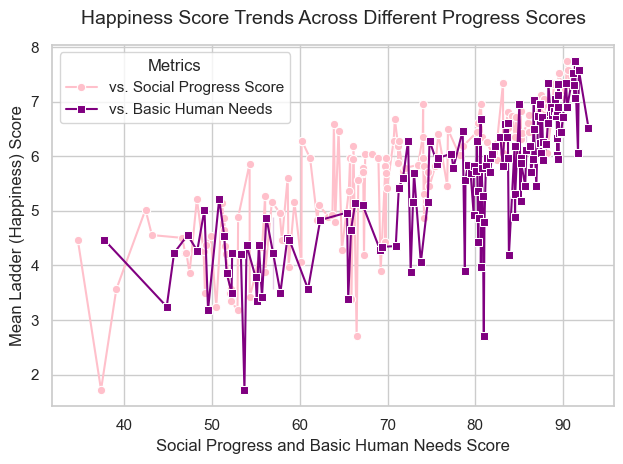

In [27]:

import matplotlib.pyplot as plt
import seaborn as sns

df_by_social = df_grouped.sort_values(by='Social Progress Score')
df_by_needs = df_grouped.sort_values(by='Basic Human Needs')

#Social Progress Score
sns.lineplot(
    data=df_by_social, x='Social Progress Score', y='ladder_score', 
    marker='o', color='pink', label='vs. Social Progress Score'
)

#Basic Human Needs
sns.lineplot(
    data=df_by_needs, x='Basic Human Needs', y='ladder_score', 
    marker='s', color='purple', label='vs. Basic Human Needs'
)

plt.title('Happiness Score Trends Across Different Progress Scores', fontsize=14, pad=15)
plt.xlabel('Social Progress and Basic Human Needs Score', fontsize=12)
plt.ylabel('Mean Ladder (Happiness) Score', fontsize=12)
plt.legend(title='Metrics')
plt.tight_layout()


plt.savefig('happiness_combined_metrics.png', dpi=300)


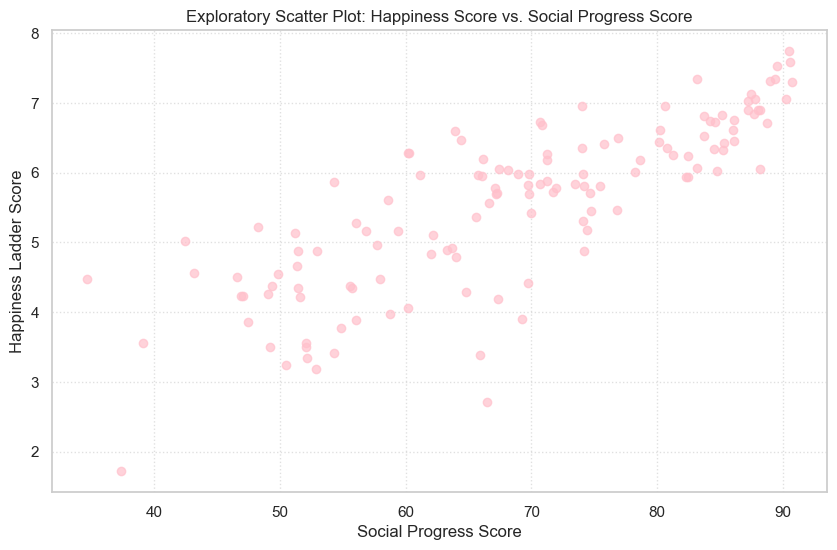

In [12]:
# Plot 2: Customized scatter plot of primary policy variables
plt.figure(figsize=(10, 6))
plt.scatter(x = df_merged['Social Progress Score'], y =df_merged['ladder_score'], color='pink', alpha=0.7)


plt.title("Exploratory Scatter Plot: Happiness Score vs. Social Progress Score")
plt.ylabel("Happiness Ladder Score")
plt.xlabel("Social Progress Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

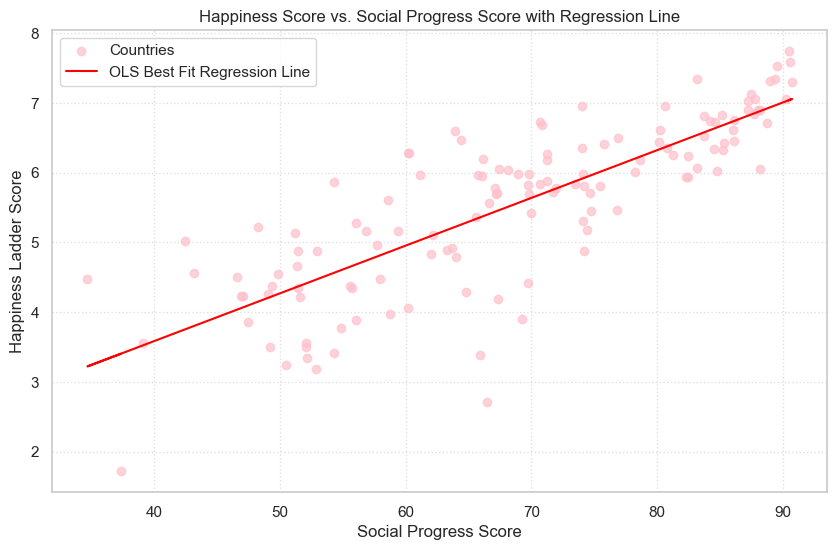

In [22]:
import statsmodels.api as sm

# Keep original setup: Happiness predicts GDP
X_real = df_merged['Social Progress Score']
y_real = df_merged['ladder_score']
X_real_const = sm.add_constant(X_real)
X_real_const.head(2)

model_real = sm.OLS(y_real, X_real_const).fit()
model_real
plt.figure(figsize=(10, 6))

# 1. X is Social Progress Score, Y is Happiness
plt.scatter(df_merged['Social Progress Score'], df_merged['ladder_score'], color='pink', alpha=0.7, label='Countries')


intercept_real, slope_real = model_real.params.iloc[0], model_real.params.iloc[1]

# 2. Match the regression line calculation to the X values (ladder_score)
plt.plot(df_merged['Social Progress Score'], intercept_real + slope_real * df_merged['Social Progress Score'], color='red', label='OLS Best Fit Regression Line')

# 3. Label the axes correctly
plt.title("Happiness Score vs. Social Progress Score with Regression Line")
plt.xlabel("Social Progress Score")
plt.ylabel("Happiness Ladder Score")

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

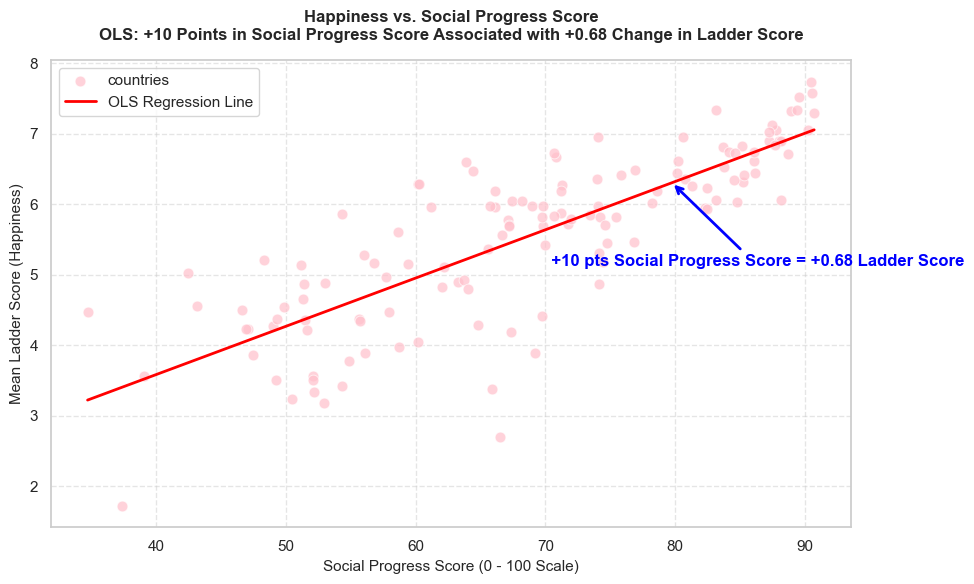

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm

# 1. Define variables based on your previous dataframe 'df_grouped'
x_col = "Social Progress Score"  # Change to 'Basic Human Needs' if preferred
y_col = "ladder_score"

# 2. Fit a standard linear OLS model: Happiness = b0 + b1 * (Social Progress Score)
X = sm.add_constant(df_grouped[x_col])
model = sm.OLS(df_grouped[y_col], X).fit()
b0, b1 = model.params.iloc[0], model.params.iloc[1]

# 3. Calculate metrics for the annotation anchor
# In a standard linear model, a 10-point increase in X yields a (10 * b1) change in Y
x1 = df_grouped[x_col].median()
x2 = x1 + 10
y1 = b0 + b1 * x1
y2 = b0 + b1 * x2
y_delta = y2 - y1

# 4. Plot the base scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_grouped,
    x=x_col,
    y=y_col,
    alpha=0.7,
    edgecolor="w",
    s=60,  # Slightly larger dots for visibility
    color= "pink",
    label="countries"
)

# 5. Plot the OLS linear regression line
x_domain = np.linspace(df_grouped[x_col].min(), df_grouped[x_col].max(), 100)
plt.plot(x_domain, b0 + b1 * x_domain, color="red", lw=2, label="OLS Regression Line")

# 6. Annotate the step change
plt.annotate(
    f"  +10 pts {x_col} = {y_delta:+.2f} Ladder Score",
    xy=(x2, y2),
    xytext=(x1, y1 - 0.5),  # Shift text down slightly so it doesn't overlap the line
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0",  # Straight arrow fits a linear model better
        color="blue",
        lw=2,
    ),
    weight="bold",
    color="blue",
)

# 7. Labels, Title, and Formatting
plt.title(
    f"Happiness vs. {x_col}\nOLS: +10 Points in {x_col} Associated with {y_delta:+.2f} Change in Ladder Score",
    fontsize=12,
    weight="bold",
    pad=15
)
plt.xlabel(f"{x_col} (0 - 100 Scale)", fontsize=11)
plt.ylabel("Mean Ladder Score (Happiness)", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()

# Save and Show
plt.savefig('happiness_linear_regression.png', dpi=300)
plt.show()

- *Extra Credit:There is a strong correlation between social progress score and mean ladder score aka happiness score. With a 10 point increase in social progress score there is a 0.68 point increase in happiness scale. 

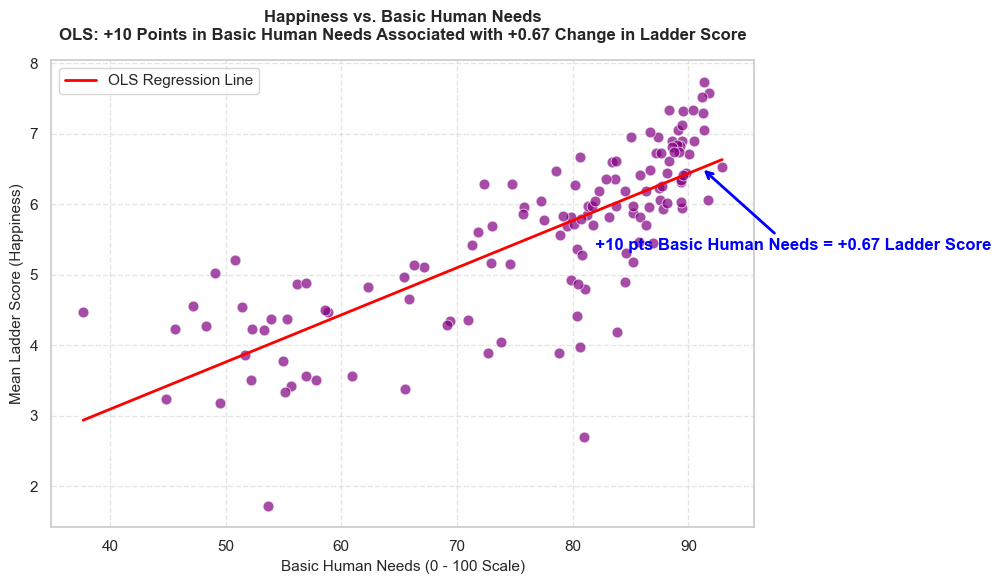

In [14]:
#Doing another one with looking at basic needs being met instead of social progress score. 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm

# 1. Define variables based on your previous dataframe 'df_grouped'
x_col = "Basic Human Needs"  
y_col = "ladder_score"

# 2. Fit a standard linear OLS model: Happiness = b0 + b1 * (Social Progress Score)
X = sm.add_constant(df_grouped[x_col])
model = sm.OLS(df_grouped[y_col], X).fit()
b0, b1 = model.params.iloc[0], model.params.iloc[1]

# 3. Calculate metrics for the annotation anchor
# In a standard linear model, a 10-point increase in X yields a (10 * b1) change in Y
x1 = df_grouped[x_col].median()
x2 = x1 + 10
y1 = b0 + b1 * x1
y2 = b0 + b1 * x2
y_delta = y2 - y1

# 4. Plot the base scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_grouped,
    x=x_col,
    y=y_col,
    alpha=0.7,
    edgecolor="w",
    s=60,  # Slightly larger dots for visibility
    color="purple"
)

# 5. Plot the OLS linear regression line
x_domain = np.linspace(df_grouped[x_col].min(), df_grouped[x_col].max(), 100)
plt.plot(x_domain, b0 + b1 * x_domain, color="red", lw=2, label="OLS Regression Line")

# 6. Annotate the step change
plt.annotate(
    f"  +10 pts {x_col} = {y_delta:+.2f} Ladder Score",
    xy=(x2, y2),
    xytext=(x1, y1 - 0.5),  # Shift text down slightly so it doesn't overlap the line
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0",  # Straight arrow fits a linear model better
        color="blue",
        lw=2,
    ),
    weight="bold",
    color="blue",
)

# 7. Labels, Title, and Formatting
plt.title(
    f"Happiness vs. {x_col}\nOLS: +10 Points in {x_col} Associated with {y_delta:+.2f} Change in Ladder Score",
    fontsize=12,
    weight="bold",
    pad=15
)
plt.xlabel(f"{x_col} (0 - 100 Scale)", fontsize=11)
plt.ylabel("Mean Ladder Score (Happiness)", fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()

# Save and Show
plt.savefig('happiness_linear_regression.png', dpi=300)
plt.show()

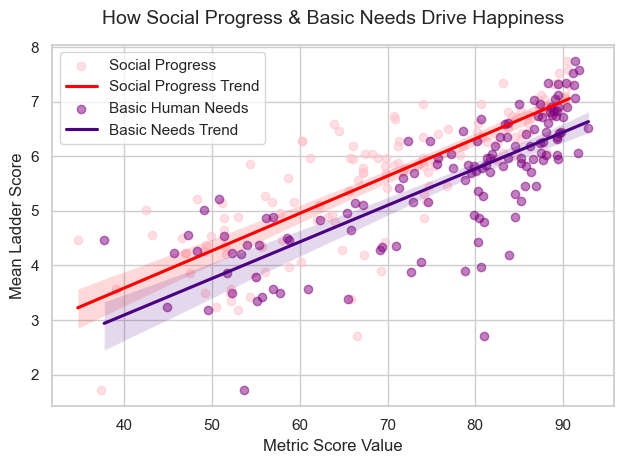

In [28]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.clf()
sns.set_theme(style="whitegrid")

# Create a scatter plot with a smooth trendline for Social Progress
sns.regplot(
    data=df_grouped, x='Social Progress Score', y='ladder_score', 
    scatter_kws={'alpha':0.5, 'color':'pink'}, line_kws={'color':'red', 'label':'Social Progress Trend'},
    label='Social Progress'
)

# Create a scatter plot with a smooth trendline for Basic Human Needs
sns.regplot(
    data=df_grouped, x='Basic Human Needs', y='ladder_score', 
    scatter_kws={'alpha':0.5, 'color':'purple'}, line_kws={'color':'indigo', 'label':'Basic Needs Trend'},
    label='Basic Human Needs'
)

plt.title('How Social Progress & Basic Needs Drive Happiness', fontsize=14, pad=15)
plt.xlabel('Metric Score Value', fontsize=12)
plt.ylabel('Mean Ladder Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('happiness_trends_scatter.png', dpi=300)

In [16]:
#rate of return is nearly identical for both social progress and basic needs. 

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.